# Diabetes Outcome Prediction: Research Notebook

This notebook documents an exploratory healthcare machine-learning study using the included diabetes dataset. The target variable, Outcome, represents the observed diabetes classification in the dataset; it is not a clinical diagnosis produced by this study.

## Study aims

1. Inspect the dataset and assess basic data quality.
2. Explore distributions, outliers, and class balance.
3. Compare several baseline supervised-learning models.
4. Examine the effect of SMOTE-based resampling and feature selection.

The workflow and stored outputs below are retained from the original analysis. Model logic, parameters, and results are not changed in this documentation pass.

# 1. Computational setup

The following cell imports the numerical, tabular, visualization, and plotting libraries used throughout the analysis. Keeping these dependencies together makes the computational environment easier to audit and reproduce.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# 2. Dataset loading and cohort definition

The dataset is loaded from the repository's data/ directory. Each row represents one observation, the clinical and demographic columns are candidate predictors, and Outcome is the binary target used for supervised learning. The displayed dataframe is retained as a first inspection of the data structure and values.

In [2]:
df=pd.read_csv('data/diabetes.csv')

In [3]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


# 3. Data-quality assessment and preprocessing

These checks examine duplicate rows, missing values, and column data types before modeling. The existing analysis records whether additional cleaning or categorical encoding is required. No imputation or encoding step is introduced here; the original preprocessing decisions and outputs are preserved.

In [4]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
763    False
764    False
765    False
766    False
767    False
Length: 768, dtype: bool

In [5]:
df.duplicated().sum()

0

In [6]:
df.isnull()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
763,False,False,False,False,False,False,False,False,False
764,False,False,False,False,False,False,False,False,False
765,False,False,False,False,False,False,False,False,False
766,False,False,False,False,False,False,False,False,False


In [7]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
#There are no duplicates or null values present in the dataset.

In [9]:
for i in df.columns:
    print(i,":",df[i].dtype)

Pregnancies : int64
Glucose : int64
BloodPressure : int64
SkinThickness : int64
Insulin : int64
BMI : float64
DiabetesPedigreeFunction : float64
Age : int64
Outcome : int64


In [10]:
#All the features present in the dataset are numerical so label encoding need not be done.

# 4. Outlier inspection and analytical subset

Boxplots are used to inspect the distributions of the predictor variables and identify potentially extreme observations. The subsequent filtering applies the IQR rule sequentially to selected variables and stores the resulting analytical subset in new_df. This is an exploratory preprocessing choice and should be validated against domain and cohort context before clinical interpretation.

Text(0.5, 1.0, 'Pregnancies')

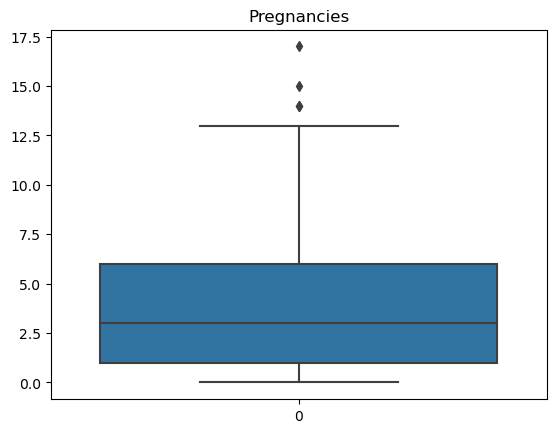

In [11]:
sns.boxplot(data=df['Pregnancies'])
plt.title('Pregnancies')

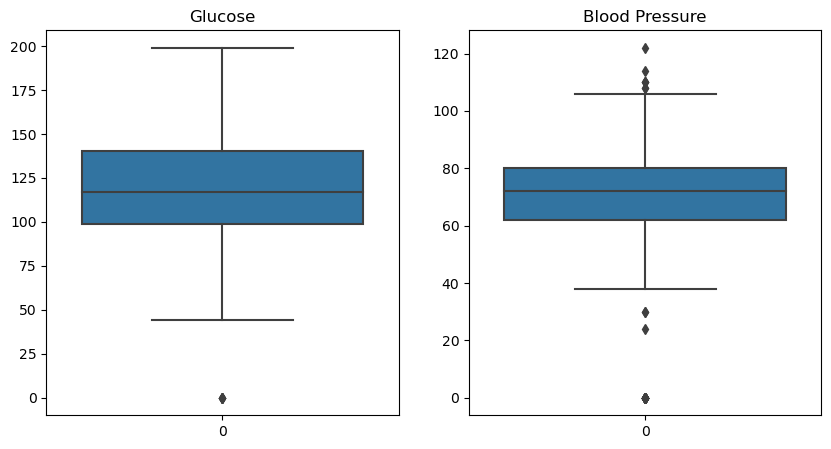

In [12]:
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
sns.boxplot(data=df['Glucose'])
plt.title('Glucose')

plt.subplot(1,2,2)
sns.boxplot(data=df['BloodPressure'])
plt.title('Blood Pressure')
plt.show()


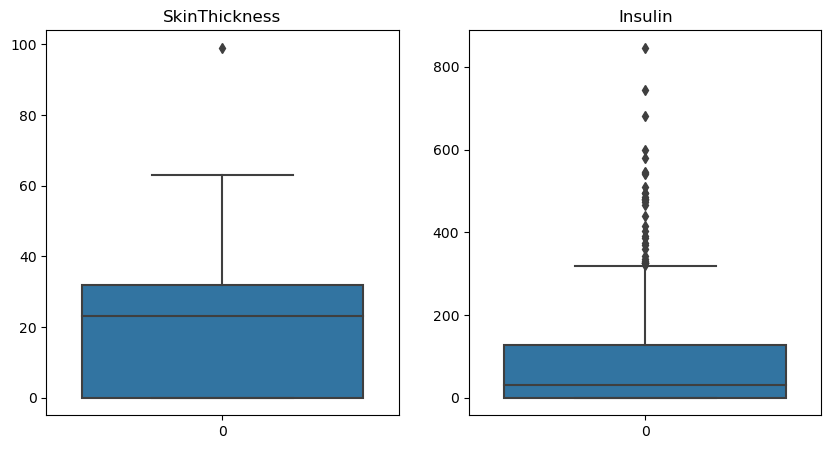

In [13]:
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
sns.boxplot(data=df['SkinThickness'])
plt.title('SkinThickness')

plt.subplot(1,2,2)
sns.boxplot(data=df['Insulin'])
plt.title('Insulin')
plt.show()

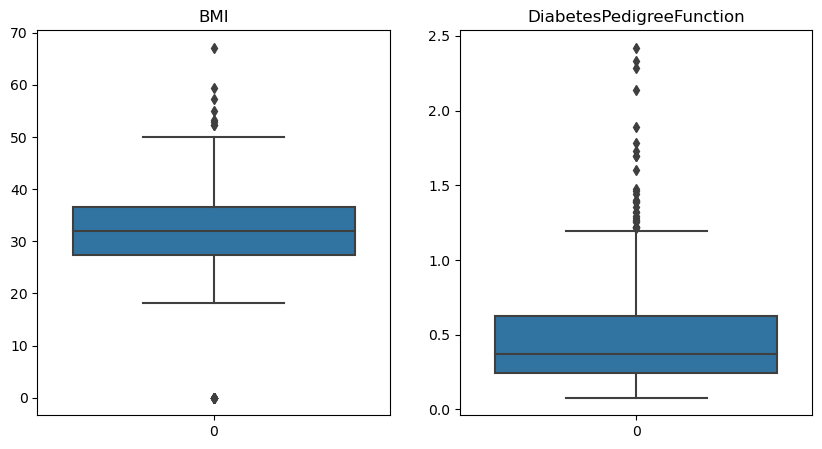

In [14]:
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
sns.boxplot(data=df['BMI'])
plt.title('BMI')

plt.subplot(1,2,2)
sns.boxplot(data=df['DiabetesPedigreeFunction'])
plt.title('DiabetesPedigreeFunction')
plt.show()

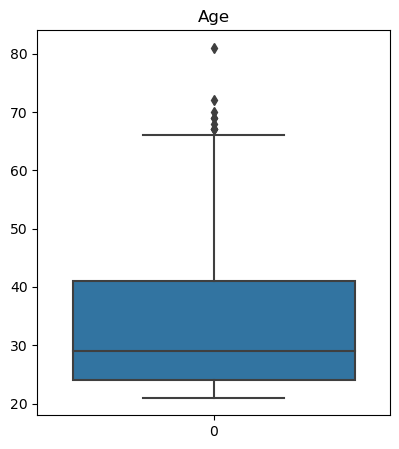

In [15]:
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
sns.boxplot(data=df['Age'])
plt.title('Age')
plt.show()


In [16]:
new_df=df.copy()

In [17]:
len(new_df)

768

In [18]:
Q1=df['Pregnancies'].quantile(0.25)
Q3=df['Pregnancies'].quantile(0.75)
IQR=Q3-Q1
new_df=df[(df["Pregnancies"] >= Q1-1.5*IQR) & (df['Pregnancies'] <= Q3+1.5*IQR)]
new_df


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [19]:
Q1=df['Glucose'].quantile(0.25)
Q3=df['Glucose'].quantile(0.75)
IQR=Q3-Q1
new_df=new_df[(new_df["Glucose"] >= Q1-1.5*IQR) & (new_df['Glucose'] <= Q3+1.5*IQR)]
new_df


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [20]:
Q1=df['BloodPressure'].quantile(0.25)
Q3=df['BloodPressure'].quantile(0.75)
IQR=Q3-Q1
new_df=new_df[(new_df["BloodPressure"] >= Q1-1.5*IQR) & (new_df['BloodPressure'] <= Q3+1.5*IQR)]
new_df


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [21]:
Q1=df['SkinThickness'].quantile(0.25)
Q3=df['SkinThickness'].quantile(0.75)
IQR=Q3-Q1
new_df=new_df[(new_df["SkinThickness"] >= Q1-1.5*IQR) & (new_df['SkinThickness'] <= Q3+1.5*IQR)]
new_df


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [22]:
Q1=df['BMI'].quantile(0.25)
Q3=df['BMI'].quantile(0.75)
IQR=Q3-Q1
new_df=new_df[(new_df["BMI"] >= Q1-1.5*IQR) & (new_df['BMI'] <= Q3+1.5*IQR)]
new_df


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


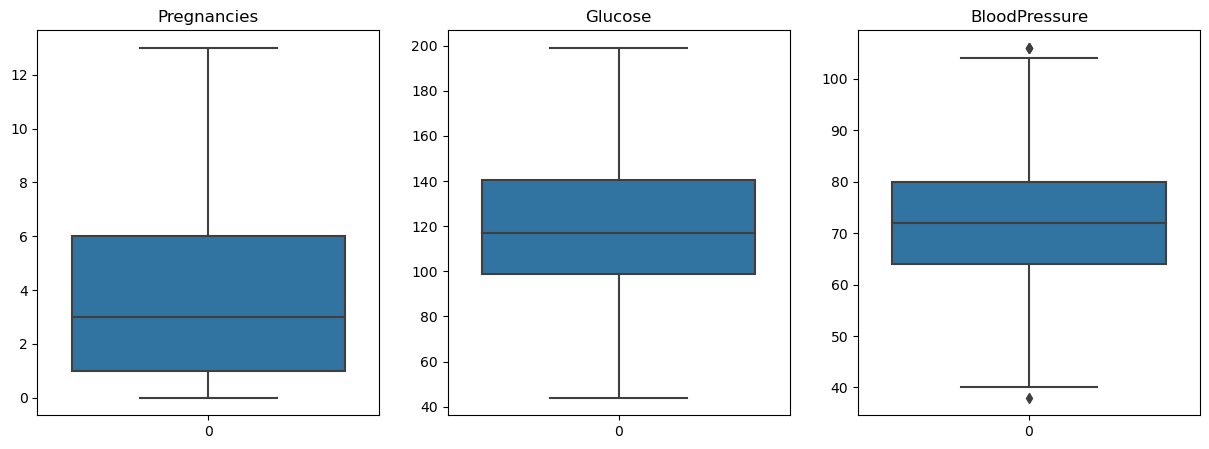

In [23]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sns.boxplot(new_df['Pregnancies'])
plt.title('Pregnancies')

plt.subplot(1,3,2)
sns.boxplot(new_df['Glucose'])
plt.title('Glucose')

plt.subplot(1,3,3)
sns.boxplot(new_df['BloodPressure'])
plt.title('BloodPressure')

plt.show()

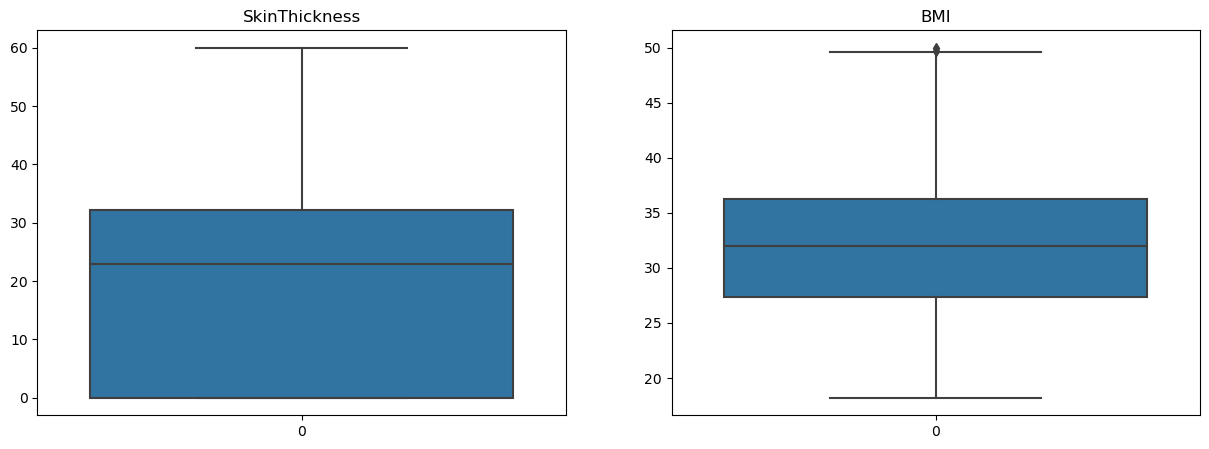

In [24]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(new_df['SkinThickness'])
plt.title('SkinThickness')

plt.subplot(1,2,2)
sns.boxplot(new_df['BMI'])
plt.title('BMI')

plt.show()

In [25]:
new_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


# 5. Exploratory data visualization

These plots summarize selected feature distributions and relationships after the exploratory filtering step. They are intended to support descriptive understanding of the cohort and to surface patterns that may affect model behavior; they do not establish causal or clinical relationships.

<Axes: xlabel='Pregnancies', ylabel='count'>

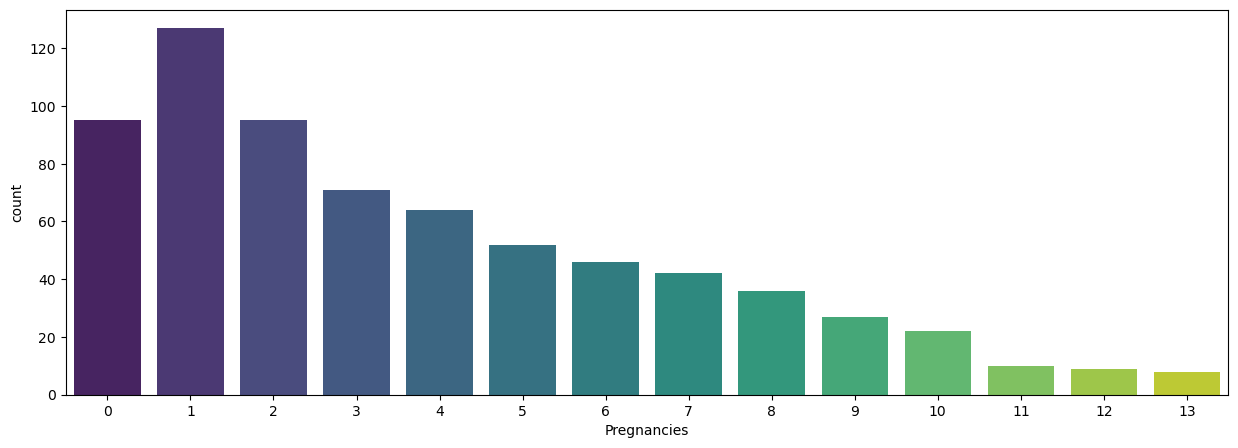

In [26]:
plt.figure(figsize=(15,5))
sns.countplot(x='Pregnancies', data=new_df, palette='viridis')

C:\Users\datma003\AppData\Local\Temp\ipykernel_19440\4217777837.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['BMI'],bins=[10,15,20,25,30,35,40,45,50,55,60])


<Axes: xlabel='BMI', ylabel='Density'>

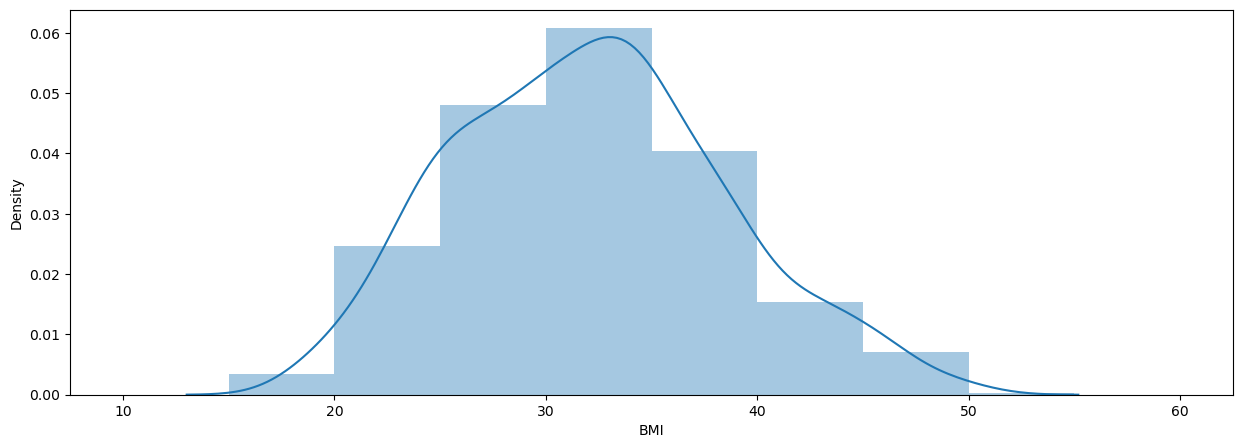

In [27]:
plt.figure(figsize=(15,5))
sns.distplot(new_df['BMI'],bins=[10,15,20,25,30,35,40,45,50,55,60])

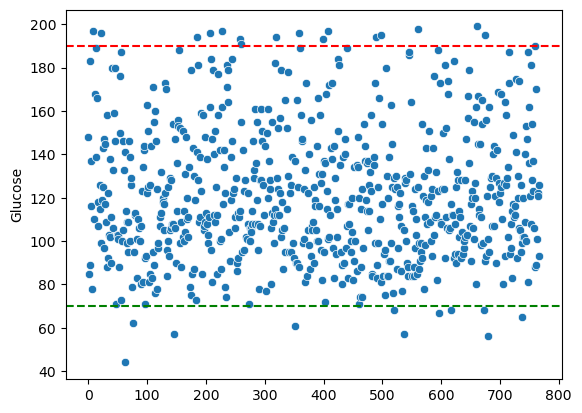

In [28]:
sns.scatterplot(new_df['Glucose'])
plt.axhline(y=190, color='red', linestyle='--')
plt.axhline(y=70, color='green', linestyle='--')

# 6. Class balance and SMOTE experiment

The target distribution is inspected before applying Synthetic Minority Over-sampling Technique (SMOTE). The resampled feature matrix and target are retained as a separate experimental dataset (x_sm, y_sm) so the original filtered observations remain available for comparison.

In [29]:
new_df['Outcome'].value_counts()

Outcome
0    468
1    236
Name: count, dtype: int64

In [30]:
from imblearn.over_sampling import SMOTE


In [31]:
X=new_df.drop(columns=['Outcome'])
Y=new_df['Outcome']

In [32]:
smote=SMOTE(sampling_strategy='minority')
x_sm,y_sm=smote.fit_resample(X,Y)

In [33]:
y_sm.value_counts(),len(x_sm)

(Outcome
 1    468
 0    468
 Name: count, dtype: int64,
 936)

# 7. Hold-out split for baseline evaluation

The filtered, non-SMOTE dataset is split into training and test partitions using stratification on Outcome. The displayed partitions and class counts make the evaluation setup inspectable before model fitting. Random-state control is not added in this pass, so exact splits may vary when the notebook is rerun.

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
X=new_df.drop('Outcome',axis=1)
Y=new_df['Outcome']

In [36]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.25,stratify=Y)

In [37]:
x_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
299,8,112,72,0,0,23.6,0.840,58
620,2,112,86,42,160,38.4,0.246,28
416,1,97,68,21,0,27.2,1.095,22
285,7,136,74,26,135,26.0,0.647,51
375,12,140,82,43,325,39.2,0.528,58
...,...,...,...,...,...,...,...,...
496,5,110,68,0,0,26.0,0.292,30
506,0,180,90,26,90,36.5,0.314,35
151,4,114,65,0,0,21.9,0.432,37
600,1,108,88,19,0,27.1,0.400,24


In [38]:
x_test

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
681,0,162,76,36,0,49.6,0.364,26
235,4,171,72,0,0,43.6,0.479,26
64,7,114,66,0,0,32.8,0.258,42
351,4,137,84,0,0,31.2,0.252,30
645,2,157,74,35,440,39.4,0.134,30
...,...,...,...,...,...,...,...,...
554,1,84,64,23,115,36.9,0.471,28
552,6,114,88,0,0,27.8,0.247,66
401,6,137,61,0,0,24.2,0.151,55
736,0,126,86,27,120,27.4,0.515,21


In [39]:
y_test.value_counts()

Outcome
0    117
1     59
Name: count, dtype: int64

# 8. Baseline model comparison and resampling evaluation

This section fits and evaluates logistic regression, support vector classification, decision tree, and random forest models using the existing hold-out workflow. Accuracy, classification reports, and confusion matrices are displayed for review. The later cells repeat the random-forest evaluation on the SMOTE-resampled data and then estimate performance with shuffled 10-fold cross-validation.

These metrics describe performance on this dataset and split only. They should not be interpreted as evidence of clinical readiness or generalization to a different population.

In [40]:
from sklearn.linear_model import LogisticRegression

In [41]:
LR=LogisticRegression()

In [42]:
LR.fit(x_train,y_train)

C:\Users\datma003\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [43]:
LR_pred=LR.predict(x_test)

In [44]:
from sklearn.metrics import *

In [45]:
accuracy_score(LR_pred,y_test)

0.7386363636363636

In [46]:
print(classification_report(LR_pred,y_test))

              precision    recall  f1-score   support

           0       0.89      0.76      0.82       137
           1       0.44      0.67      0.53        39

    accuracy                           0.74       176
   macro avg       0.66      0.71      0.67       176
weighted avg       0.79      0.74      0.76       176



<Axes: >

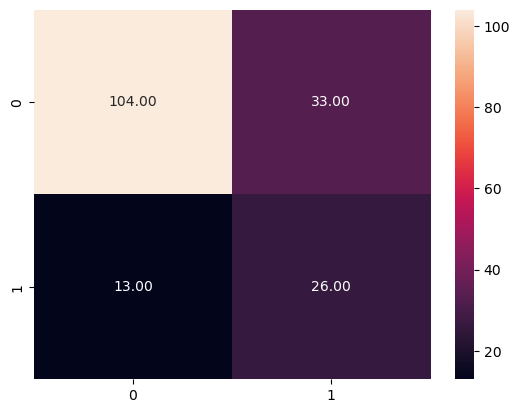

In [47]:
sns.heatmap(confusion_matrix(LR_pred,y_test),annot=True,fmt=".2f")

In [48]:
from sklearn.svm import SVC

In [49]:
SVM=SVC()

In [50]:
SVM.fit(x_train,y_train)

SVC()

In [51]:
SVM_pred=SVM.predict(x_test)

In [52]:
accuracy_score(SVM_pred,y_test)

0.7215909090909091

In [53]:
print(classification_report(SVM_pred,y_test))

              precision    recall  f1-score   support

           0       0.88      0.75      0.81       138
           1       0.41      0.63      0.49        38

    accuracy                           0.72       176
   macro avg       0.64      0.69      0.65       176
weighted avg       0.78      0.72      0.74       176



<Axes: >

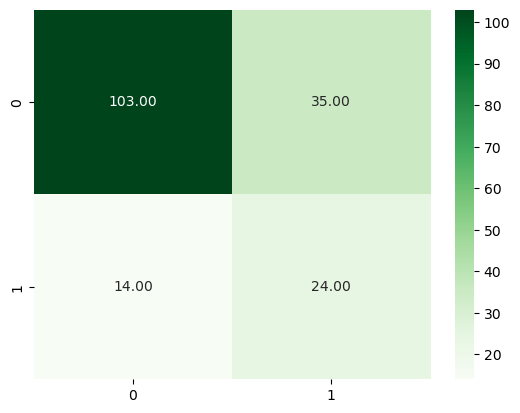

In [54]:
sns.heatmap(confusion_matrix(SVM_pred,y_test),annot=True,fmt=".2f",cmap='Greens')

In [55]:
from sklearn.tree import DecisionTreeClassifier


In [56]:
DT=DecisionTreeClassifier()

In [57]:
DT.fit(x_train,y_train)

DecisionTreeClassifier()

In [58]:
DT_pred=DT.predict(x_test)

In [59]:
accuracy_score(DT_pred,y_test)

0.6988636363636364

In [60]:
print(classification_report(DT_pred,y_test))

              precision    recall  f1-score   support

           0       0.74      0.80      0.76       108
           1       0.63      0.54      0.58        68

    accuracy                           0.70       176
   macro avg       0.68      0.67      0.67       176
weighted avg       0.69      0.70      0.69       176



<Axes: >

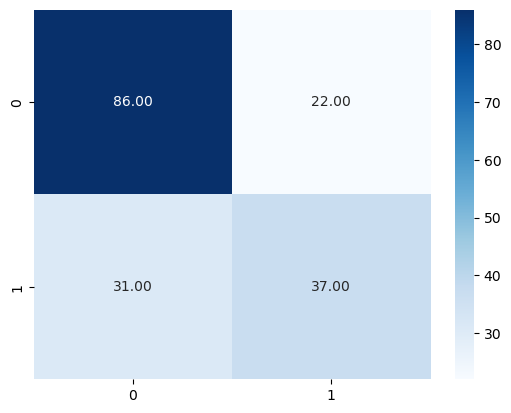

In [61]:
sns.heatmap(confusion_matrix(DT_pred,y_test),annot=True,fmt=".2f",cmap='Blues')

In [62]:
from sklearn.ensemble import RandomForestClassifier

In [63]:
RF=RandomForestClassifier()

In [64]:
RF.fit(x_train,y_train)

RandomForestClassifier()

In [65]:
RF_pred=RF.predict(x_test)

In [66]:
accuracy_score(RF_pred,y_test)

0.75

In [67]:
print(classification_report(RF_pred,y_test))

              precision    recall  f1-score   support

           0       0.86      0.78      0.82       129
           1       0.53      0.66      0.58        47

    accuracy                           0.75       176
   macro avg       0.69      0.72      0.70       176
weighted avg       0.77      0.75      0.76       176



<Axes: >

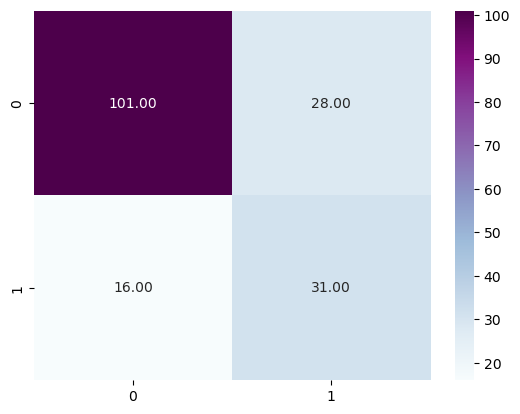

In [68]:
sns.heatmap(confusion_matrix(RF_pred,y_test),annot=True,fmt=".2f",cmap='BuPu')

In [69]:
x_train,x_test,y_train,y_test=train_test_split(x_sm,y_sm,test_size=0.25,stratify=y_sm)

In [70]:
y_sm.value_counts()

Outcome
1    468
0    468
Name: count, dtype: int64

In [71]:
RF.fit(x_train,y_train)

RandomForestClassifier()

In [72]:
Smote_pred=RF.predict(x_test)

In [73]:
accuracy_score(Smote_pred,y_test)

0.8162393162393162

<Axes: >

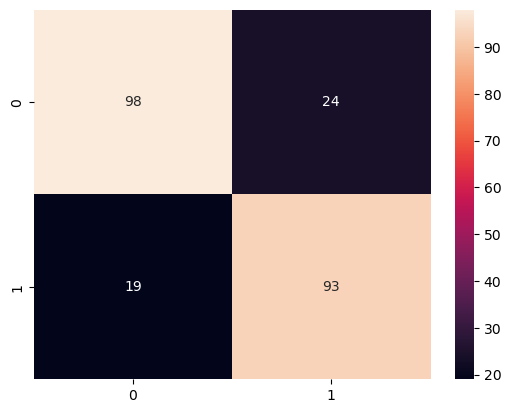

In [76]:
sns.heatmap(confusion_matrix(Smote_pred,y_test),annot=True)

In [77]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

In [78]:
KRF=RandomForestClassifier()

In [79]:
kf = KFold(n_splits=10, shuffle=True)

In [80]:
cross_val_results = cross_val_score(KRF,x_sm, y_sm, cv=kf)

In [81]:
print("Cross-Validation Results:", cross_val_results)
print("Max Accuracy:", np.max(cross_val_results))

Cross-Validation Results: [0.82978723 0.79787234 0.80851064 0.74468085 0.81914894 0.85106383
 0.76344086 0.91397849 0.87096774 0.80645161]
Max Accuracy: 0.9139784946236559


# 9. Feature selection and model interpretation

The final section investigates whether a smaller predictor set can retain useful predictive signal. It contains two complementary analyses: univariate selection with chi-squared SelectKBest, followed by model-based feature-importance inspection using the random forest.

## 9.1 Univariate selection with SelectKBest

The helper function ranks eligible numerical predictors using the chi-squared score and retains the top four features. The analysis applies this procedure to the filtered data and to the SMOTE-resampled data, then evaluates a reduced random-forest feature set using the existing test and cross-validation cells.

In [82]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

In [83]:
def FS_KBest(df):

    #Feature selection using KBest
    col_list = []
    for col in df.columns:
        if ((df[col].dtype != 'object') & (col != 'Outcome') ):
            col_list.append(col)
        
    xx=df[col_list]
    yy=df['Outcome']
    fs=SelectKBest(score_func=chi2,k=4)
    X_selected=fs.fit_transform(xx,yy)
    l=list(xx.columns)
    for i in range(0,len(l)):
        print(f"{i} = {l[i]}")
        
    return fs.get_support(True)

In [84]:
FS_KBest(new_df)

0 = Pregnancies
1 = Glucose
2 = BloodPressure
3 = SkinThickness
4 = Insulin
5 = BMI
6 = DiabetesPedigreeFunction
7 = Age


array([0, 1, 4, 7], dtype=int64)

In [85]:
smote_df=x_sm
smote_df['Outcome']=y_sm

In [86]:
smote_df.Outcome.value_counts()

Outcome
1    468
0    468
Name: count, dtype: int64

In [87]:
FS_KBest(smote_df)

0 = Pregnancies
1 = Glucose
2 = BloodPressure
3 = SkinThickness
4 = Insulin
5 = BMI
6 = DiabetesPedigreeFunction
7 = Age


array([1, 4, 5, 7], dtype=int64)

In [88]:
df_4=smote_df.drop(columns=['BloodPressure','SkinThickness','DiabetesPedigreeFunction',"BMI"])
x_4=smote_df.drop('Outcome',axis=1)
y_4=smote_df['Outcome']

In [89]:
x_train,x_test,y_train,y_test=train_test_split(x_4,y_4,test_size=0.25,stratify=y_4)

In [90]:
RF.fit(x_train,y_train)

RandomForestClassifier()

In [91]:
Smote_pred_4=RF.predict(x_test)

In [92]:
accuracy_score(Smote_pred_4,y_test)

0.8162393162393162

In [93]:
cross_val_results = cross_val_score(KRF,x_4, y_4, cv=kf)

In [94]:
print("Cross-Validation Results:", cross_val_results)
print("Max Accuracy:", np.max(cross_val_results))

Cross-Validation Results: [0.82978723 0.86170213 0.84042553 0.81914894 0.81914894 0.90425532
 0.74193548 0.83870968 0.84946237 0.79569892]
Max Accuracy: 0.9042553191489362


## 9.2 Random-forest feature importance

Random-forest importance scores provide a model-specific view of which predictors contributed most to the fitted ensemble. The final experiment removes a subset of lower-ranked variables and evaluates the resulting feature set. These scores are associative model diagnostics, not causal evidence about diabetes risk.

In [95]:
feature_importances = RF.feature_importances_

In [96]:
feature_importance_df = pd.DataFrame({'Feature': range(0, len(feature_importances)),
                                      'Importance': feature_importances})

In [97]:
feature_importance_df.sort_values(by='Importance',ascending=False)

,Feature,Importance
1,1,0.264799
5,5,0.186055
7,7,0.137446
6,6,0.131078
2,2,0.080270
0,0,0.069569
4,4,0.069333
3,3,0.061450


In [98]:
x_feature_imp=x_sm.drop(columns=['Pregnancies','SkinThickness','Insulin','BloodPressure'])
y_feature_imp=y_sm

In [99]:
x_train,x_test,y_train,y_test=train_test_split(x_feature_imp,y_feature_imp,test_size=0.25,stratify=y_feature_imp)

In [100]:
RF.fit(x_train,y_train)

RandomForestClassifier()

In [101]:
Smote_pred_feature_imp=RF.predict(x_test)

In [102]:
accuracy_score(Smote_pred_feature_imp,y_test)

1.0

In [103]:
cross_val_results = cross_val_score(KRF,x_feature_imp, y_feature_imp, cv=kf)

In [288]:
print("Cross-Validation Results:", cross_val_results)
print("Max Accuracy:", np.max(cross_val_results))

Cross-Validation Results: [0.84042553 0.81914894 0.73404255 0.73404255 0.74468085 0.82978723
 0.79569892 0.83870968 0.77419355 0.80645161]
Max Accuracy: 0.8404255319148937


## 10. Interpretation and next research steps

The stored outputs provide an initial comparison of model behavior under the original and resampled workflows. A professor reviewing this work should read the results together with the preprocessing choices, validation design, and dataset limitations rather than treating the highest accuracy as a definitive model-selection criterion.

Before making stronger claims, the study would benefit from documenting dataset provenance and cohort definition, adding fixed random seeds, separating resampling from validation folds to avoid leakage, reporting metrics beyond accuracy, and evaluating performance on an external or temporally held-out cohort. None of those methodological changes are made in this documentation-only revision.